## Librerias

In [20]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from textblob import TextBlob
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

## Importación de los datos limpios

In [21]:
path = 'datos/datos_clean.csv'
df = pd.read_csv(path)

df['texto'] = df['texto'].astype(str)
df['texto_clean'] = df['texto_clean'].astype(str)

## Calculo de los embedings

In [22]:
embedding_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

docs = df['texto'].astype(str).tolist()

embeddings = embedding_model.encode(
    docs,
    show_progress_bar=True
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

## Análisis de polaridad

In [23]:
# Descargamos las stopwords
nltk.download('stopwords')
stop_words_es = stopwords.words('spanish')

# Función para calcular la polaridad (de -1.0 a 1.0)
def calcular_polaridad(texto):
    # Nota: TextBlob funciona nativamente en inglés. 
    # Usamos una traducción interna rápida al inglés para evaluar textos en español.
    try:
        analisis = TextBlob(texto).translate(from_lang='es', to='en')
        return analisis.sentiment.polarity
    except:
        # En caso de error de conexión con el traductor, usamos el original
        return TextBlob(texto).sentiment.polarity

# Aplicamos la función y creamos una nueva columna
df['polaridad'] = df['texto_clean'].apply(calcular_polaridad)

# Etiquetamos el resultado para hacerlo más legible
df['sentimiento'] = df['polaridad'].apply(
    lambda p: 'Positivo' if p > 0.1 else ('Negativo' if p < -0.1 else 'Neutral')
)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\joanm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Topic modeling

In [27]:
stopwords_es = [
    'de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se',
    'las', 'por', 'un', 'para', 'con', 'no', 'una', 'su', 'al',
    'lo', 'es', 'si', 'ha', 'más', 'pero', 'sus', 'le', 'ya',
    'o', 'este', 'sí', 'porque', 'esta', 'entre', 'cuando',
    'muy', 'sin', 'sobre', 'también', 'me', 'hasta', 'hay',
    'donde', 'quien', 'desde', 'todo', 'nos', 'durante',
    'todos', 'uno', 'les', 'ni', 'contra', 'otros', 'ese',
    'eso', 'ante', 'ellos', 'e', 'esto', 'mí', 'antes',
    'algunos', 'qué', 'unos', 'yo', 'otro', 'otras', 'otra',
    'él', 'tanto', 'esa', 'estos', 'mucho', 'quienes', 'nada',
    'muchos', 'cual', 'poco', 'ella', 'estar', 'estas',
    'algunas', 'algo', 'nosotros', 'como', 'ser', 'son', 'está', 
    'han', 'sino', 'solo'
]

mis_stopwords = list(set(stopwords_es))

In [28]:
#  Reduce dimensionality
umap_model = UMAP(
    n_neighbors=7,   # Número de vecinos para construir el grafo de proximidad en el espacio de alta dimensión. Un valor más alto puede capturar mejor la estructura global, mientras que un valor más bajo se enfoca en la estructura local.
    n_components=5,   # Número de dimensiones a las que se reducirá el espacio de embeddings. Un valor más bajo puede facilitar la visualización y el clustering, pero también puede perder información relevante.
    min_dist=0.0,      
    metric="cosine",  
    random_state=42
)

# Cluster reduced embeddings
hdbscan_model = HDBSCAN(
    min_cluster_size=200,   # Número mínimo de documentos por tema. Un valor más bajo puede generar más temas, pero también puede incluir temas menos coherentes.
    min_samples=7,        # Controla lo estricto que es HDBSCAN para considerar que una zona es realmente un cluster (en función de la densidad de muestras). Un valor más bajo puede generar más clusters, pero también puede incluir clusters menos coherentes.
    metric="euclidean",   # Métrica de distancia para calcular la similitud entre documentos
    cluster_selection_method="eom", # Método de selección de clusters "excess of mass" que prioriza clusters densos y bien definidos.
    prediction_data=True
)

# Tokenize topics
vectorizer_model = CountVectorizer(
    stop_words=mis_stopwords,
    min_df=2,
    ngram_range=(1, 2)
)

# Create topic representation
ctfidf_model = ClassTfidfTransformer()

# All steps together
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    language="multilingual",
    verbose=True
)

topics, probs = topic_model.fit_transform(
    docs,
    embeddings
)

df['id_tema'] = topics

display(df[['texto', 'periodico', 'id_tema']])

2026-05-07 21:41:40,212 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


2026-05-07 21:41:53,871 - BERTopic - Dimensionality - Completed ✓
2026-05-07 21:41:53,873 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-07 21:41:54,275 - BERTopic - Cluster - Completed ✓
2026-05-07 21:41:54,280 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-07 21:42:11,895 - BERTopic - Representation - Completed ✓


,texto,periodico,id_tema
0,En la competición de visualizaciones del vídeo...,eldiario.es,0
1,Hay asuntos que una no abandona al salir del j...,eldiario.es,0
2,En la competición de visualizaciones del vídeo...,eldiario.es,0
3,Como un gélido bisturí explorador de las mise...,eldiario.es,0
4,Un minuto y diez segundos. Eso es lo que dura ...,eldiario.es,0
...,...,...,...
9995,"abascal y sánchez, en una sesión de control. e...",el español,0
9996,los argumentos del actual portavoz paradisputa...,el español,0
9997,"pedro sánchez y oriol junqueras, este jueves e...",el español,0
9998,quiso el destino que el último día de campaña ...,el español,0


In [29]:
unique_topics = sorted(set(topics))

for topic_id in unique_topics:
    if topic_id == -1:
        continue

    print("\n" + "=" * 80)
    print(f"TOPIC {topic_id}")

    words = topic_model.get_topic(topic_id)
    topic_words = [word for word, score in words[:10]]

    print(topic_words)


TOPIC 0
['sánchez', 'gobierno', 'años', 'españa', 'política', 'dos', 'vez', 'era', 'puede', 'pp']

TOPIC 1
['españa', 'personas', 'años', 'gobierno', 'vivienda', 'millones', 'social', 'puede', 'animales', 'cada']

TOPIC 2
['trump', 'estados', 'unidos', 'estados unidos', 'guerra', 'venezuela', 'china', 'mundo', 'rusia', 'eeuu']

TOPIC 3
['israel', 'gaza', 'palestina', 'genocidio', 'palestino', 'israelí', 'pueblo', 'palestinos', 'estado', 'internacional']

TOPIC 4
['irán', 'israel', 'guerra', 'trump', 'estados', 'unidos', 'estados unidos', 'iraní', 'nuclear', 'régimen']

TOPIC 5
['fascismo', 'mundo', 'capitalismo', 'mundial', 'países', 'social', 'fue', 'china', 'poder', 'global']


In [32]:
#print de los coherence scores de los topics
tokenized_docs = [doc.lower().split() for doc in docs]

# Diccionario de Gensim:
# palabra -> ID único
dictionary = Dictionary(tokenized_docs)

print("=" * 80)
print("COHERENCE SCORE POR TOPIC")
print("=" * 80)

for topic_id in unique_topics:

    # Ignorar outliers de BERTopic
    if topic_id == -1:
        continue

    # Obtener palabras representativas del topic
    words = topic_model.get_topic(topic_id)

    # Seleccionar las 10 palabras más importantes
    topic_words = [word for word, score in words[:10]]

    # El coherence model espera una lista de topics,
    # aunque aquí solo evaluemos uno
    coherence_model = CoherenceModel(
        topics=[topic_words],
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence="c_v"
    )

    # Calcular coherence del topic individual
    coherence = coherence_model.get_coherence()

    print(f"Topic {topic_id}: {coherence:.4f}")

COHERENCE SCORE POR TOPIC
Topic 0: 0.3908
Topic 1: 0.3584
Topic 2: 0.7237
Topic 3: 0.8136
Topic 4: 0.7554
Topic 5: 0.4888


In [33]:
df.head(5)

,periodico,titulo,texto,url,texto_clean,polaridad,sentimiento,id_tema
0,eldiario.es,La resaca de El Alcoraz,En la competición de visualizaciones del vídeo...,https://www.eldiario.es/aragon/el-prismatico/r...,competición visualización vídeo impactante ara...,0.061538,Neutral,0
1,eldiario.es,Juicio a Vivotecnia: cómo demostrar un exceso...,Hay asuntos que una no abandona al salir del j...,https://www.eldiario.es/caballodenietzsche/jui...,asunto abandonar salir juzgado caso quedar adh...,0.071429,Neutral,0
2,eldiario.es,La resaca de El Alcoraz,En la competición de visualizaciones del vídeo...,https://www.eldiario.es/aragon/el-prismatico/r...,competición visualización vídeo impactante ara...,0.061538,Neutral,0
3,eldiario.es,Mentiras y cintas de vídeo,Como un gélido bisturí explorador de las mise...,https://www.eldiario.es/aragon/el-prismatico/m...,gélido bisturí explorador miseria humano defin...,0.212500,Positivo,0
4,eldiario.es,Vosotros sois la televisión,Un minuto y diez segundos. Eso es lo que dura ...,https://www.eldiario.es/aragon/el-prismatico/t...,minuto segundo durar vídeo informativo televis...,0.000000,Neutral,0


## Temas en función del periodico

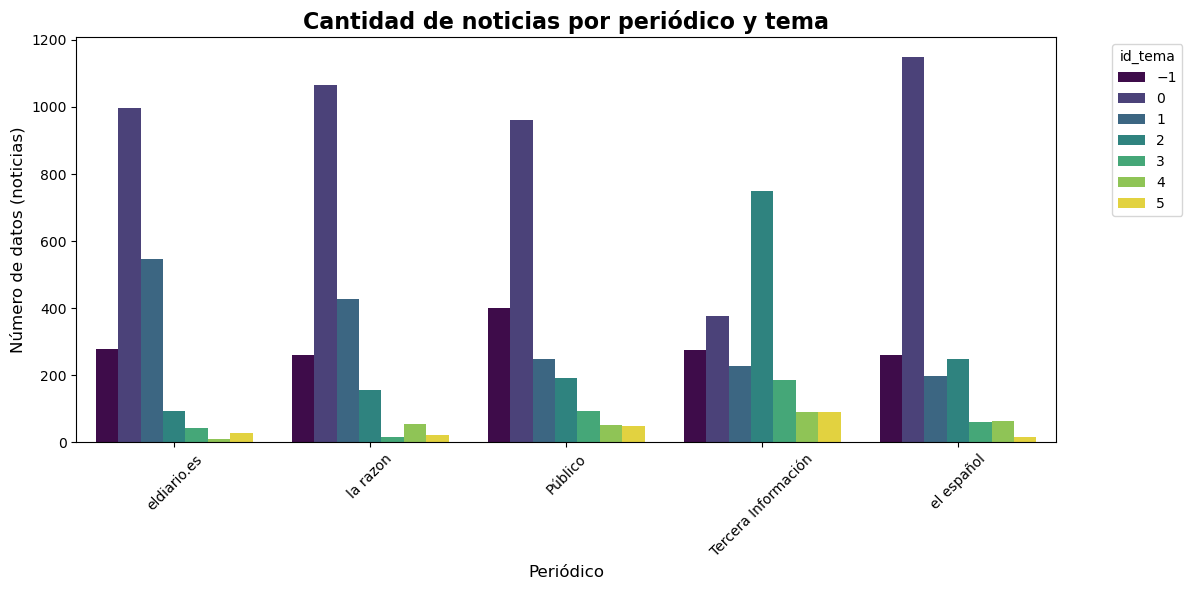

In [34]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='periodico', hue='id_tema', palette='viridis')
plt.title('Cantidad de noticias por periódico y tema', fontsize=16, fontweight='bold')
plt.xlabel('Periódico', fontsize=12)
plt.ylabel('Número de datos (noticias)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='id_tema', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Polaridad en función del periodico y del tema

In [35]:
df_pol = pd.DataFrame()
sel_tema = 3

list_dic = []

periodicos = df['periodico'].unique()

for i in periodicos:
    
    df_sub = df[(df['periodico'] == i) & (df['id_tema'] == sel_tema)]

    dic = {
        'Periodico': i,
        'Positivo': len(df_sub[df_sub['sentimiento'] == 'Positivo']),
        'Negativo': len(df_sub[df_sub['sentimiento'] == 'Negativo']),
        'Neutral': len(df_sub[df_sub['sentimiento'] == 'Neutral'])
    }
    list_dic.append(dic)

df_pol = pd.DataFrame(list_dic)
print(df_pol)

             Periodico  Positivo  Negativo  Neutral
0          eldiario.es         7         7       30
1             la razon         3         4       10
2              Público        19        21       55
3  Tercera Información        33        69       83
4           el español         6        17       39


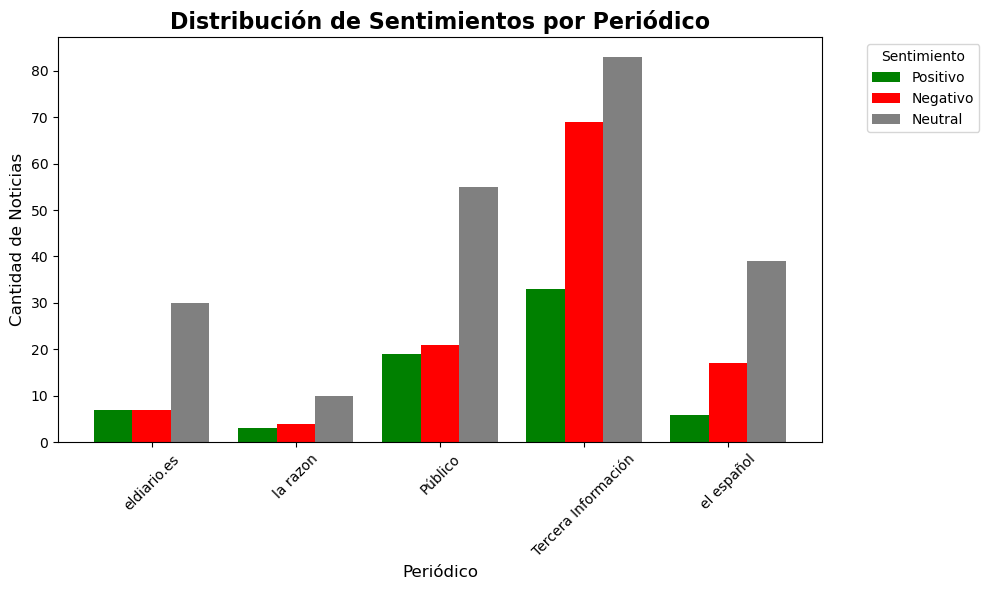

In [36]:
datos_grafica = df_pol.set_index('Periodico')[['Positivo', 'Negativo', 'Neutral']]
datos_grafica.plot(kind='bar', figsize=(10, 6), color=['green', 'red', 'gray'], width=0.8)
plt.title('Distribución de Sentimientos por Periódico', fontsize=16, fontweight='bold')
plt.xlabel('Periódico', fontsize=12)
plt.ylabel('Cantidad de Noticias', fontsize=12)
plt.xticks(rotation=45) 
plt.legend(title='Sentimiento', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Preparación de datos para entrenamiento de modelos

Codelist:

* **X** -> noticias en el espacio numérico de dimensión reducida
* **y1** -> predicción de periodicos
* **y2** -> predicción de temas

In [42]:
# Obtenemos el modelo de umap
umap_trained = topic_model.umap_model

# Calculamos las variables en el espacio reducido
X = umap_trained.transform(embeddings)
X

array([[-0.5810461 ,  3.325051  , -0.35794204,  0.48271278, 11.912491  ],
       [ 0.5588886 ,  2.4205933 ,  2.4651244 ,  2.4947915 , 11.649391  ],
       [-0.582914  ,  3.3259768 , -0.3535518 ,  0.4868358 , 11.908883  ],
       ...,
       [ 0.3095736 ,  2.816458  ,  0.10298507,  0.44744176, 11.781339  ],
       [-0.19528888,  4.0484014 ,  1.7615794 ,  1.4780254 , 12.358261  ],
       [ 0.23296234,  4.522556  ,  0.98648906,  1.8754942 , 12.456146  ]],
      shape=(10000, 5), dtype=float32)

In [ ]:
y1 = df[['periodico']]
y1.head(5)

,periodico
0,eldiario.es
1,eldiario.es
2,eldiario.es
3,eldiario.es
4,eldiario.es


In [46]:
y2 = df[['id_tema']]
y2.head(5)

,id_tema
0,0
1,0
2,0
3,0
4,0
